# Limit Cycles

> **Learning goal:** Understand isolated closed trajectories — why they exist, how to prove they cannot, and why they are the mathematical skeleton of rhythm, spiking neurons, and inference stability in AI.

## 1. What Is a Limit Cycle?

**Textbook definition (Strogatz §7.0):** A limit cycle is an **isolated closed trajectory** in phase space.

The word *isolated* is load-bearing. The simple harmonic oscillator $\ddot{x} + x = 0$ also has closed orbits — but infinitely many, nested, and all neutrally stable. Perturb it and you land on a *different* orbit and stay there. A limit cycle is different: it is **self-correcting**. Perturb a heartbeat or a walking gait and the nonlinear dynamics return it to the *exact same* frequency and amplitude.

This self-correction comes from the sign of the **Floquet exponent** (the analogue of $f'(x^*)$ for periodic orbits):

- **Stable limit cycle:** nearby trajectories spiral *in* — the cycle is an attractor.
- **Unstable limit cycle:** nearby trajectories spiral *out*.
- **Half-stable:** stable from one side, unstable from the other.

**AGI Relevance:** Repetitive hallucinations in LLMs — the model looping the same phrase indefinitely — are conceptually modelled as the hidden state being trapped in an *unwanted stable limit cycle*. This is an analogy and active research framing, not a proved theorem about transformers, but it motivates the engineering proposals in §4 below.

## 2. Ruling Out Closed Orbits — The "No-Go" Theorems

Before proving a cycle exists, Strogatz (§7.2) teaches us to prove one *cannot*. This is the mathematics of **formal verification**.

### 2A. Gradient Systems

**The theorem:** If $\dot{\mathbf{x}} = -\nabla V(\mathbf{x})$, the system has no closed orbits.

**Proof sketch:** Along any trajectory, $\dot{V} = \nabla V \cdot \dot{\mathbf{x}} = -|\nabla V|^2 \leq 0$. $V$ is a strict Lyapunov function — it decreases monotonically. A closed orbit would require $V$ to return to its starting value, contradicting strict decrease. $\blacksquare$

**Deep Learning link:** Continuous-time gradient descent $\dot{\theta} = -\nabla L(\theta)$ is a gradient system — it provably cannot oscillate. This gives theoretical grounding for why standard loss-descent converges rather than cycling.

> **Important distinction:** This applies to *continuous-time* GD. Discrete GD with a large learning rate absolutely can oscillate or diverge — the step size $\eta$ breaks the continuous-time guarantee. This is why learning rate schedules and adaptive optimisers (Adam, RMSProp) exist: they implicitly regularise the discrete update to stay near the continuous-time flow.

**Corollary for design:** If you want an agent to exhibit periodic behaviour — rhythmic curiosity, scanning, or oscillatory attention — you *must* introduce non-gradient terms: momentum, external forcing, or explicit oscillatory dynamics.

### 2B. Dulac's Criterion

**The theorem (Strogatz §7.2):** For a system $\dot{\mathbf{x}} = \mathbf{f}(\mathbf{x})$ in a simply connected region $R$, if there exists a smooth function $g(\mathbf{x})$ such that:

$$\nabla \cdot \bigl(g(\mathbf{x})\,\mathbf{f}(\mathbf{x})\bigr)$$

has one sign throughout $R$, then there are no closed orbits in $R$.

**AI Safety link:** Dulac's criterion is a tool for *formally guaranteeing* that a model's state-space flow will never enter an infinite loop. If a Dulac function can be found for the state transition dynamics of an agent, we have a mathematical certificate that the agent always terminates or reaches an equilibrium — a prerequisite for provably safe AGI.

## 3. The Poincaré–Bendixson Theorem — The 2D Ceiling

**The theorem (Strogatz §7.3):** Suppose a trajectory is confined to a closed, bounded region $R$ and $R$ contains no fixed points. Then the trajectory must approach a closed orbit (limit cycle).

**The "No Chaos in 2D" corollary:** Poincaré–Bendixson proves that in two dimensions, long-run behaviour is limited to:
1. Convergence to a fixed point
2. Convergence to a limit cycle
3. The trajectory itself is a closed orbit

Chaos — aperiodic, sensitive-dependence-on-initial-conditions behaviour — is **impossible in 2D**. It requires at least $n = 3$ dimensions (the Lorenz system being the canonical example).

**AGI dimensionality argument:** A model whose internal state lives in an effectively 2D latent space is mathematically limited to "stop" or "loop." For genuine creativity, flexible reasoning, and emergent complexity, the latent space must have dimension $\geq 3$. This is not a heuristic — it is a topological theorem.

## 4. Relaxation Oscillations & Two-Timing

### 4A. Van der Pol and Relaxation Oscillations (Strogatz §7.5)

The Van der Pol oscillator:

$$\ddot{x} + \mu(x^2 - 1)\dot{x} + x = 0$$

Written as a 2D system:

$$\dot{x} = v \qquad \dot{v} = \mu(1 - x^2)v - x$$

**The nonlinear damping mechanism:**
- When $|x| < 1$: the factor $(1 - x^2) > 0$ — energy is **pumped in** (negative damping).
- When $|x| > 1$: the factor $(1 - x^2) < 0$ — energy is **drained** (positive damping).

This self-regulating energy exchange produces a globally attracting limit cycle for all $\mu > 0$.

For large $\mu$, the cycle becomes a **relaxation oscillator**: slow charge along the $x$-nullcline, then fast discharge — a spike.

**Spiking Neural Network (SNN) link:** This is the exact mathematics of the FitzHugh–Nagumo neuron model (a simplified Hodgkin–Huxley). The slow buildup is the membrane potential rising; the fast discharge is the action potential firing. The Van der Pol / FitzHugh–Nagumo family is the standard mathematical skeleton of biological spiking.

### 4B. Two-Timing — Multiscale Analysis (Strogatz §7.6)

For systems with a small parameter $\epsilon \ll 1$ (e.g. weak nonlinearity), solutions can be approximated by splitting time into two independent scales:

$$\tau = t \quad \text{(fast time)} \qquad T = \epsilon t \quad \text{(slow time)}$$

The solution is written as $x(\tau, T)$, and derivatives expand as:

$$\frac{d}{dt} = \frac{\partial}{\partial \tau} + \epsilon\,\frac{\partial}{\partial T}$$

Secular terms (resonant divergences) are eliminated by choosing $T$-dynamics appropriately — this yields a uniformly valid approximation.

**World Model / Hierarchical AI link:** Two-timing formalises the idea of **temporal hierarchy**:

| Scale | AI Analogue |
|---|---|
| Fast time $\tau$ | Processing the current token / video frame |
| Slow time $T$ | Tracking the high-level goal / intent / plan |

Most current LLM architectures treat all tokens at the same temporal scale. Two-timing mathematics suggests that architectures with **explicit slow-fast separation** — processing local syntax on $\tau$ and global intent on $T$ — would be more principled. This connects directly to Mamba's selective state compression and hierarchical transformer designs.

## 5. Code: Four Visualisations

### 5A. Limit Cycle Stability — Phase Portrait & Nullclines

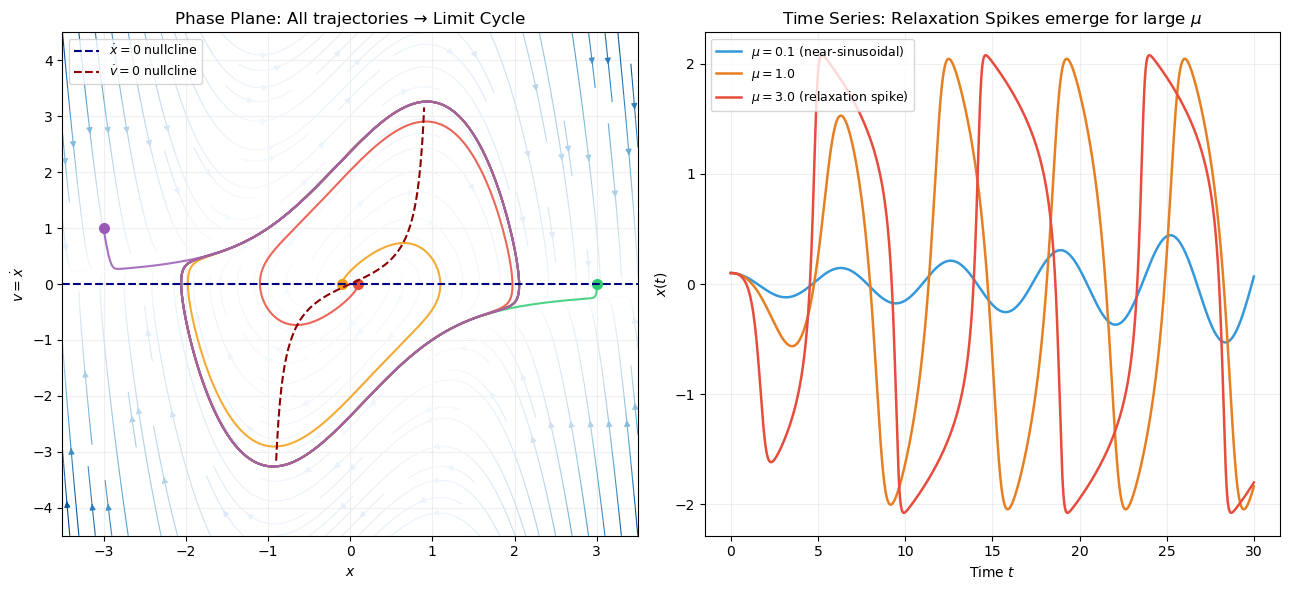

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def vdp(state, mu):
    x, v = state
    return np.array([v, mu * (1 - x**2) * v - x])

def euler(f, s0, t_end, dt=0.02):
    t = np.arange(0, t_end, dt)
    s = np.empty((len(t), 2)); s[0] = s0
    for i in range(1, len(t)):
        s[i] = s[i-1] + f(s[i-1]) * dt
    return t, s

mu = 1.5
x_r = np.linspace(-3.5, 3.5, 400)
v_r = np.linspace(-4.5, 4.5, 400)
X, V = np.meshgrid(x_r, v_r)

DX =  V
DV = mu * (1 - X**2) * V - X
speed = np.sqrt(DX**2 + DV**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# ── Panel 1: streamlines + trajectories ──────────────────────────
ax = axes[0]
ax.streamplot(X, V, DX, DV, color=speed, cmap="Blues",
              linewidth=0.8, density=1.2, arrowsize=0.9)

# trajectories from inside and outside the cycle
for s0, c in [([0.1, 0.0], "#E74C3C"), ([3.0, 0.0], "#2ECC71"),
              ([-0.1, 0.0], "#F39C12"), ([-3.0, 1.0], "#9B59B6")]:
    _, traj = euler(lambda s: vdp(s, mu), s0, t_end=20)
    ax.plot(traj[:,0], traj[:,1], color=c, lw=1.5, alpha=0.85)
    ax.plot(traj[0,0], traj[0,1], "o", color=c, ms=7)

# nullclines: dx/dt=0 => v=0; dv/dt=0 => v = x / (mu*(1-x^2))
ax.axhline(0, color="navy", lw=1.5, ls="--", label=r"$\dot{x}=0$ nullcline")
x_nc = np.linspace(-0.9, 0.9, 200)
v_nc = x_nc / (mu * (1 - x_nc**2))
ax.plot(x_nc, v_nc, color="darkred", lw=1.5, ls="--", label=r"$\dot{v}=0$ nullcline")

ax.set_xlim(-3.5, 3.5); ax.set_ylim(-4.5, 4.5)
ax.set_xlabel(r"$x$"); ax.set_ylabel(r"$v = \dot{x}$")
ax.set_title("Phase Plane: All trajectories → Limit Cycle")
ax.legend(fontsize=9); ax.grid(True, alpha=0.2)

# ── Panel 2: time series for different mu (relaxation) ───────────
ax2 = axes[1]
t_long = np.arange(0, 30, 0.02)
for mu_val, c, lbl in [(0.1, "#3498DB", r"$\mu=0.1$ (near-sinusoidal)"),
                        (1.0, "#E67E22", r"$\mu=1.0$"),
                        (3.0, "#E74C3C", r"$\mu=3.0$ (relaxation spike)")]:
    _, traj = euler(lambda s, m=mu_val: vdp(s, m), [0.1, 0.0], t_end=30)
    ax2.plot(t_long[:len(traj)], traj[:,0], color=c, lw=1.8, label=lbl)

ax2.set_xlabel("Time $t$"); ax2.set_ylabel("$x(t)$")
ax2.set_title(r"Time Series: Relaxation Spikes emerge for large $\mu$")
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### 5B. Gradient System Cannot Oscillate — Proof by Simulation

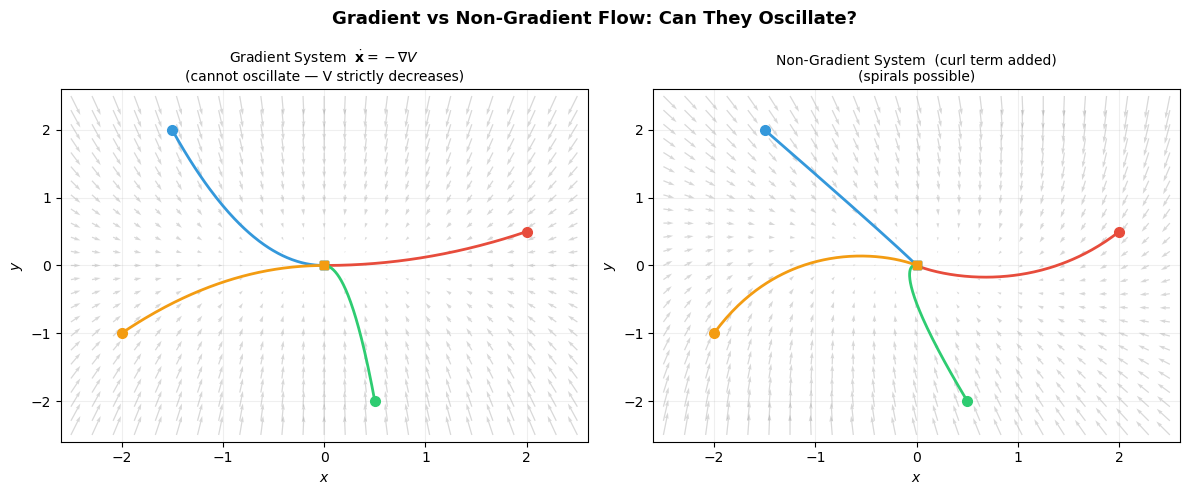

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ── Gradient system: V(x,y) = x^2 + 2y^2  (an elliptic bowl) ────
def grad_flow(state):
    x, y = state
    # dot{state} = -grad V = [-2x, -4y]
    return np.array([-2*x, -4*y])

# ── Non-gradient system: rotation + gradient ──────────────────────
def non_grad_flow(state):
    x, y = state
    # Adds a curl term -> closed orbit possible
    return np.array([-2*x + y, -x - 4*y])

def euler(f, s0, t_end=5, dt=0.01):
    t = np.arange(0, t_end, dt)
    s = np.empty((len(t), 2)); s[0] = s0
    for i in range(1, len(t)):
        s[i] = s[i-1] + f(s[i-1]) * dt
    return t, s

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Gradient vs Non-Gradient Flow: Can They Oscillate?",
             fontsize=13, fontweight="bold")

starts = [[2.0, 0.5], [-1.5, 2.0], [0.5, -2.0], [-2.0, -1.0]]
colors = ["#E74C3C", "#3498DB", "#2ECC71", "#F39C12"]

for ax, flow, title in zip(
    axes,
    [grad_flow, non_grad_flow],
    [r"Gradient System  $\dot{\mathbf{x}} = -\nabla V$" + "\n(cannot oscillate — V strictly decreases)",
     "Non-Gradient System  (curl term added)\n(spirals possible)"]):

    x_r = np.linspace(-2.5, 2.5, 25)
    y_r = np.linspace(-2.5, 2.5, 25)
    Xg, Yg = np.meshgrid(x_r, y_r)
    # evaluate field
    U = np.zeros_like(Xg); W = np.zeros_like(Yg)
    for i in range(Xg.shape[0]):
        for j in range(Xg.shape[1]):
            d = flow(np.array([Xg[i,j], Yg[i,j]]))
            U[i,j], W[i,j] = d
    ax.quiver(Xg, Yg, U, W, alpha=0.3, color="gray")

    for s0, c in zip(starts, colors):
        _, traj = euler(flow, s0, t_end=5)
        ax.plot(traj[:,0], traj[:,1], color=c, lw=2)
        ax.plot(traj[0,0], traj[0,1], "o", color=c, ms=7)
        ax.plot(traj[-1,0], traj[-1,1], "s", color=c, ms=6)

    ax.set_xlim(-2.6, 2.6); ax.set_ylim(-2.6, 2.6)
    ax.set_xlabel(r"$x$"); ax.set_ylabel(r"$y$")
    ax.set_title(title, fontsize=10); ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### 5C. Poincaré–Bendixson — Trapping Region Demo

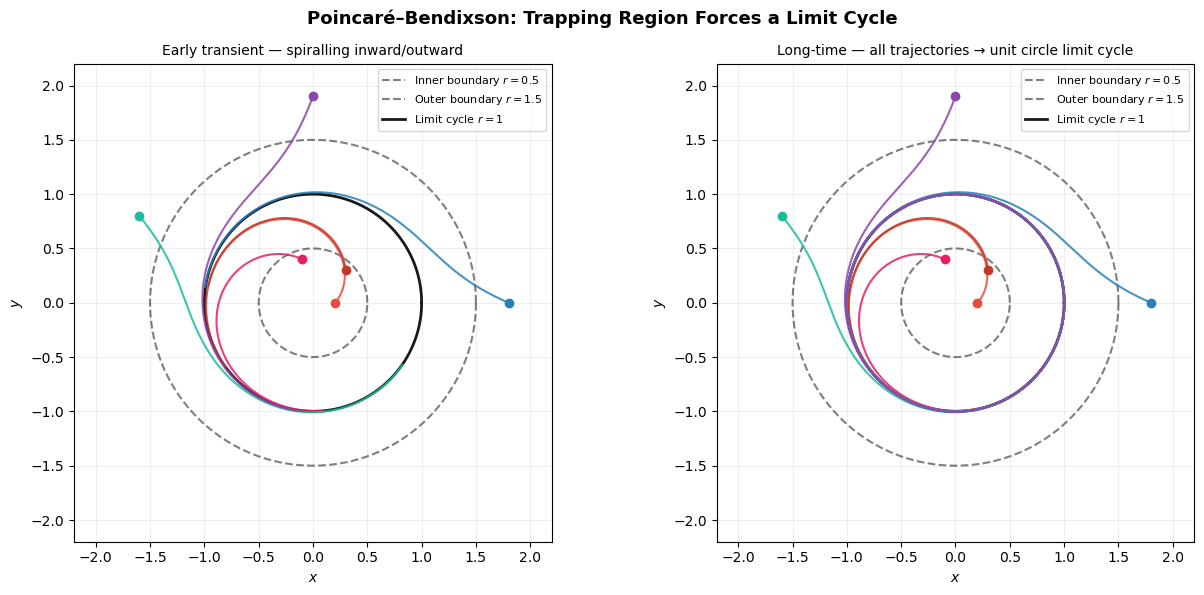

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ── System with a confirmed limit cycle (annular trapping region) ─
# dx/dt = x - y - x*(x^2+y^2)
# dy/dt = x + y - y*(x^2+y^2)
# In polar: r_dot = r(1 - r^2),  theta_dot = 1
# Fixed point only at origin (inside inner radius).
# Choose trapping annulus: 0.5 <= r <= 1.5

def annular_flow(state):
    x, y = state
    r2 = x**2 + y**2
    dx = x - y - x * r2
    dy = x + y - y * r2
    return np.array([dx, dy])

def euler(f, s0, t_end=15, dt=0.01):
    t = np.arange(0, t_end, dt)
    s = np.empty((len(t), 2)); s[0] = s0
    for i in range(1, len(t)):
        s[i] = s[i-1] + f(s[i-1]) * dt
    return t, s

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle("Poincaré–Bendixson: Trapping Region Forces a Limit Cycle",
             fontsize=13, fontweight="bold")

theta_circ = np.linspace(0, 2*np.pi, 300)

for ax, t_end, title in zip(
    axes, [3, 15],
    ["Early transient — spiralling inward/outward",
     "Long-time — all trajectories → unit circle limit cycle"]):

    # draw trapping annulus
    for r, ls, lbl in [(0.5, "--", r"Inner boundary $r=0.5$"),
                        (1.5, "--", r"Outer boundary $r=1.5$"),
                        (1.0, "-",  r"Limit cycle $r=1$")]:
        ax.plot(r*np.cos(theta_circ), r*np.sin(theta_circ),
                "k", ls=ls, lw=1.5+(r==1.0)*0.5, alpha=0.5+(r==1.0)*0.4,
                label=lbl)

    # trajectories from inside and outside the annulus
    starts_in  = [[0.2, 0.0], [0.3, 0.3], [-0.1, 0.4]]
    starts_out = [[1.8, 0.0], [-1.6, 0.8], [0.0, 1.9]]

    for s0, c in zip(starts_in,  ["#E74C3C","#C0392B","#E91E63"]):
        _, traj = euler(annular_flow, s0, t_end=t_end)
        ax.plot(traj[:,0], traj[:,1], color=c, lw=1.5, alpha=0.85)
        ax.plot(traj[0,0], traj[0,1], "o", color=c, ms=6)

    for s0, c in zip(starts_out, ["#2980B9","#1ABC9C","#8E44AD"]):
        _, traj = euler(annular_flow, s0, t_end=t_end)
        ax.plot(traj[:,0], traj[:,1], color=c, lw=1.5, alpha=0.85)
        ax.plot(traj[0,0], traj[0,1], "o", color=c, ms=6)

    ax.set_xlim(-2.2, 2.2); ax.set_ylim(-2.2, 2.2)
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x$"); ax.set_ylabel(r"$y$")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, loc="upper right"); ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### 5D. Van der Pol Guardrail — Inference Drift Correction

> **Framing:** The following is an *engineering analogy / research proposal*, not a proved result about LLMs. It demonstrates that a Van der Pol-type dynamical regulariser can correct drift in a 2D hidden state, motivating its exploration as an architectural primitive.

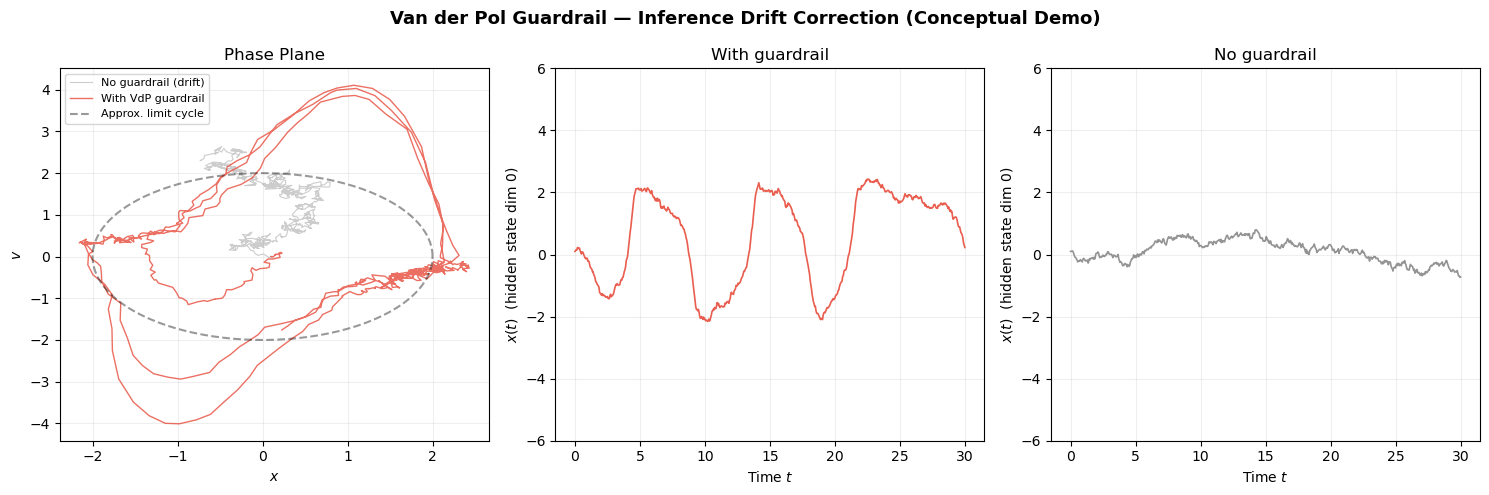

Guardrail  | std(x) = 1.460  |  max|x| = 2.43
No guardrail| std(x) = 0.361  |  max|x| = 0.79


In [11]:
import numpy as np
import matplotlib.pyplot as plt

def vanderpol_gate(h, mu=2.0):
    """
    Dynamical guardrail for a 2D hidden state h = [x, v].
    Nonlinear damping pumps energy in when |x| < 1, drains when |x| > 1.
    The limit cycle acts as a 'healthy reasoning manifold'.
    """
    x, v = h[0], h[1]
    dxdt = v
    dvdt = -mu * (x**2 - 1) * v - x   # equivalent to mu*(1-x^2)*v - x
    return np.array([dxdt, dvdt])

np.random.seed(42)
dt = 0.05
n_steps = 600

# ── Scenario A: with guardrail ────────────────────────────────────
state_g = np.array([0.1, 0.0])
history_g = [state_g.copy()]
for _ in range(n_steps):
    noise = np.random.normal(0, 0.05, size=2)
    state_g = state_g + vanderpol_gate(state_g) * dt + noise
    history_g.append(state_g.copy())

# ── Scenario B: no guardrail (pure noise walk) ────────────────────
state_n = np.array([0.1, 0.0])
history_n = [state_n.copy()]
for _ in range(n_steps):
    noise = np.random.normal(0, 0.05, size=2)
    state_n = state_n + noise
    history_n.append(state_n.copy())

history_g = np.array(history_g)
history_n = np.array(history_n)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Van der Pol Guardrail — Inference Drift Correction (Conceptual Demo)",
             fontsize=13, fontweight="bold")

# Phase plane comparison
ax = axes[0]
ax.plot(history_n[:,0], history_n[:,1], color="#AAAAAA", lw=0.8, alpha=0.6,
        label="No guardrail (drift)")
ax.plot(history_g[:,0], history_g[:,1], color="#E74C3C", lw=1.0, alpha=0.8,
        label="With VdP guardrail")

theta = np.linspace(0, 2*np.pi, 200)
# approximate VdP limit cycle amplitude ~2 for mu=2
ax.plot(2*np.cos(theta), 2*np.sin(theta), "k--", lw=1.5, alpha=0.4,
        label="Approx. limit cycle")
ax.set_xlabel(r"$x$"); ax.set_ylabel(r"$v$")
ax.set_title("Phase Plane"); ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

# x(t) time series
t_axis = np.arange(n_steps+1) * dt
for ax_t, hist, c, lbl in zip(
    axes[1:],
    [history_g, history_n],
    ["#E74C3C", "#888888"],
    ["With guardrail", "No guardrail"]):
    ax_t.plot(t_axis, hist[:,0], color=c, lw=1.2, alpha=0.9)
    ax_t.set_xlabel("Time $t$"); ax_t.set_ylabel(r"$x(t)$  (hidden state dim 0)")
    ax_t.set_title(lbl); ax_t.grid(True, alpha=0.2)
    ax_t.set_ylim(-6, 6)

plt.tight_layout()
plt.show()

# ── Quantitative summary ─────────────────────────────────
print(f"Guardrail  | std(x) = {history_g[:,0].std():.3f}  |  max|x| = {np.abs(history_g[:,0]).max():.2f}")
print(f"No guardrail| std(x) = {history_n[:,0].std():.3f}  |  max|x| = {np.abs(history_n[:,0]).max():.2f}")

## 6. Two-Timing Demo — Slow / Fast Scale Separation

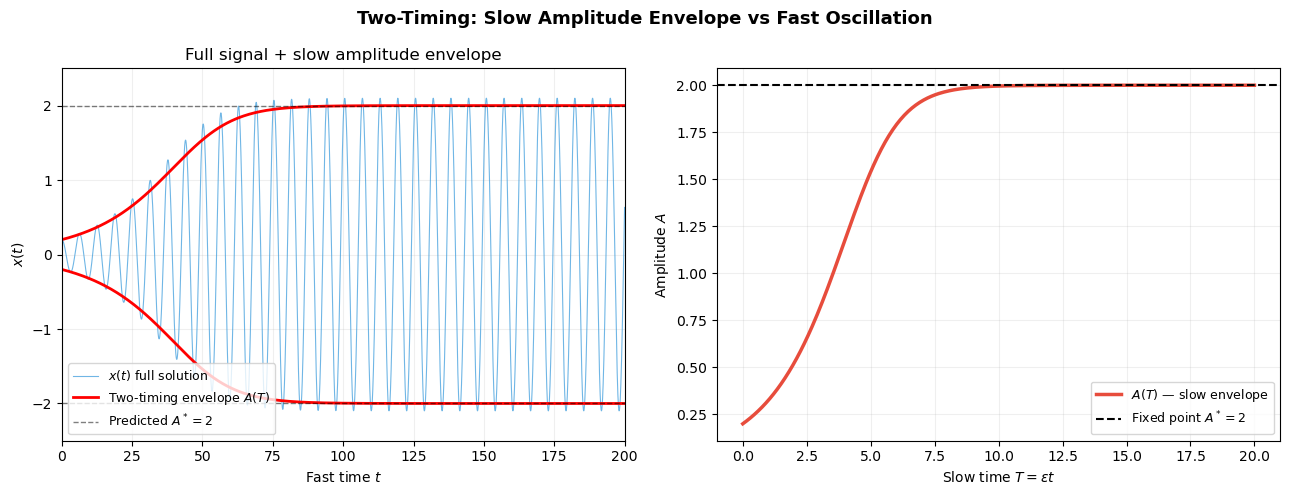

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ── Weakly nonlinear VdP: epsilon << 1 ───────────────────────
# x'' + x = epsilon*(1-x^2)*x'
# Two-timing prediction: amplitude A(T) satisfies
#   dA/dT = (A/2)*(1 - A^2/4)
# Equilibrium amplitude: A* = 2

def vdp_weak(state, eps=0.1):
    x, v = state
    return np.array([v, eps * (1 - x**2) * v - x])

def euler(f, s0, t_end, dt=0.01):
    t = np.arange(0, t_end, dt)
    s = np.empty((len(t), 2)); s[0] = s0
    for i in range(1, len(t)):
        s[i] = s[i-1] + f(s[i-1]) * dt
    return t, s

eps = 0.1

# Two-timing amplitude envelope A(T)
T_vals = np.linspace(0, 20, 400)
# dA/dT = A/2 * (1 - A^2/4)  => solve via Euler on slow time
A = 0.2   # initial amplitude (small start)
A_trace = [A]
dT = T_vals[1] - T_vals[0]
for _ in range(len(T_vals)-1):
    A = A + (A/2) * (1 - A**2/4) * dT
    A_trace.append(A)
A_trace = np.array(A_trace)

# Full numerical solution
t_num, traj = euler(lambda s: vdp_weak(s, eps), [0.2, 0.0], t_end=200, dt=0.01)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Two-Timing: Slow Amplitude Envelope vs Fast Oscillation",
             fontsize=13, fontweight="bold")

# ── Left: x(t) full signal with slow envelope overlaid ───────────
ax = axes[0]
ax.plot(t_num, traj[:,0], color="#3498DB", lw=0.8, alpha=0.7, label=r"$x(t)$ full solution")
# slow envelope on slow-time axis T = eps*t
t_slow = T_vals / eps        # convert slow time back to real time
ax.plot(t_slow,  A_trace, "r-", lw=2, label=r"Two-timing envelope $A(T)$")
ax.plot(t_slow, -A_trace, "r-", lw=2)
ax.axhline(2.0,  color="black", ls="--", lw=1, alpha=0.5, label=r"Predicted $A^*=2$")
ax.axhline(-2.0, color="black", ls="--", lw=1, alpha=0.5)
ax.set_xlim(0, 200); ax.set_ylim(-2.5, 2.5)
ax.set_xlabel(r"Fast time $t$"); ax.set_ylabel(r"$x(t)$")
ax.set_title("Full signal + slow amplitude envelope")
ax.legend(fontsize=9); ax.grid(True, alpha=0.2)

# ── Right: amplitude convergence on slow time axis ───────────────
ax2 = axes[1]
ax2.plot(T_vals, A_trace, "#E74C3C", lw=2.5, label=r"$A(T)$ — slow envelope")
ax2.axhline(2.0, color="black", ls="--", lw=1.5, label=r"Fixed point $A^*=2$")
ax2.set_xlabel(r"Slow time $T = \epsilon t$")
ax2.set_ylabel("Amplitude $A$")
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

> **What to observe:** The fast oscillation (blue) has frequency $\approx 1$ throughout. Its amplitude is modulated by the slow-time dynamics (red envelope) which converge to $A^* = 2$ exactly as the two-timing ODE predicts. The two scales are completely decoupled — this is the mathematical foundation for hierarchical temporal architectures.


```
Limit Cycles
├── Definition: Isolated closed orbits (self-correcting rhythm)
│   └── Contrast: neutrally stable orbits of the SHO
│
├── NO-GO theorems (ruling out cycles)
│   ├── Gradient systems: V̇ = -|∇V|² ≤ 0  →  no closed orbits
│   │   └── AI: continuous-time GD always settles
│   └── Dulac's criterion: div(g·f) one-sign  →  no closed orbits
│       └── AI: formal termination proofs for safe agents
│
├── Existence (Poincaré–Bendixson)
│   ├── Bounded region + no fixed points  →  limit cycle exists
│   ├── Chaos impossible in 2D
│   └── AI: latent space needs n ≥ 3 for complexity
│
├── Relaxation Oscillations (Van der Pol, large μ)
│   ├── Slow buildup + fast discharge = spike
│   └── AI: Spiking Neural Networks (FitzHugh–Nagumo family)
│
└── Two-Timing (multiscale, ε << 1)
    ├── Fast time τ = t  |  Slow time T = εt
    └── AI: token-level dynamics vs goal-level dynamics
```

## Summary Table

| Concept | Math | AI Relevance |
|---|---|---|
| Stable limit cycle | Floquet exponent < 0 | Self-correcting rhythm; unwanted loops in inference |
| Gradient system | $\dot{\mathbf{x}} = -\nabla V$ | Continuous-time GD cannot oscillate |
| Dulac's criterion | $\nabla\cdot(g\mathbf{f})$ one-sign | Formal proof of agent termination |
| Poincaré–Bendixson | Bounded + no FP → limit cycle | Chaos needs $n \geq 3$ dimensions |
| Van der Pol / relaxation | $\ddot{x} + \mu(x^2-1)\dot{x}+x=0$ | Spiking neurons; inference guardrail (proposal) |
| Two-timing | $\tau = t$, $T = \epsilon t$ | Token-scale vs goal-scale temporal hierarchy |

## References

- Strogatz, S. H. — *Nonlinear Dynamics and Chaos*, Ch. 7 (§7.0 – §7.6)
- FitzHugh (1961), Nagumo et al. (1962) — reduced neuron models from Van der Pol
- Maass, W. (1997) — *Networks of spiking neurons: The third generation of neural network models*
- Hafner et al. (2023) — *Mastering diverse domains through world models* (DreamerV3)